# import library

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

# merge data

In [ ]:
data_path = '/home/agung/Documents/alcr/ABC2026 Sozolab Challenge-20260110T085845Z-1-001/ABC2026 Sozolab Challenge/Dataset/BLE Data'

file_name = '4 day'

rssi_list = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16', '17','18','19','20', '21','22', '23','24','25']

mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

file_list = os.listdir(data_path)

csv_data = []
for csv_file in file_list:
  csv_data.append(pd.read_csv(os.path.join(data_path,csv_file),names=['user_id','timestamp','name', 'mac address', 'RSSI', 'power']))

df = csv_data[0]
for i in range(1,len(csv_data)):
  df = pd.concat([df,csv_data[i]])

print(df.shape)
df.head(5)

In [ ]:
# df.to_csv('df_concatenated.csv', index=False)

# load data

In [ ]:
df = pd.read_csv('../../dataset/df_concatenated.csv')
label = pd.read_csv('../../dataset/Dataset/5f_label_loc_train.csv')

# eda

In [ ]:
print(df.info())

print(label.info())

## rssi

In [ ]:
df.head(1)

In [ ]:
print(df['user_id'].value_counts())
print(df['name'].value_counts())

In [ ]:
print(df['mac address'].nunique())
print(df['power'].nunique())
print(df['RSSI'].nunique())

In [ ]:
plt.hist(df['power'])

In [ ]:
plt.hist(df['RSSI'])

## label

In [ ]:
label.head(1)

In [ ]:
print(label['activity'].value_counts())
print(label['user_id'].value_counts())
print(label['user'].value_counts())
print(label['room'].value_counts())
print(label['floor'].value_counts())

# preprocessing

## cleaning

In [ ]:
df = df.drop(columns=['name'])

label = label.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'user', 'floor'])

In [ ]:
# rename agar jelas
label = label.rename(columns={
    'started_at': 'start_time',
    'finished_at': 'stop_time'
})

# parse waktu
label['start_time'] = pd.to_datetime(label['start_time'], errors='coerce')
label['stop_time']  = pd.to_datetime(label['stop_time'], errors='coerce')

# hitung durasi
label['duration'] = (label['stop_time'] - label['start_time']).dt.total_seconds()

# filter valid
label = label[
    label['start_time'].notna() &
    label['stop_time'].notna() &
    (label['duration'] > 0) &
    label['deleted_at'].isna()
]

# hapus null penting & duplikat
label = label.dropna(subset=['room'])
label = label.drop_duplicates()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]

In [ ]:
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Tokyo')
label['start_time'] = label['start_time'].dt.tz_convert('Asia/Tokyo')
label['stop_time'] = label['stop_time'].dt.tz_convert('Asia/Tokyo')

In [ ]:
label = label.loc[label['activity'] == 'Location']
label = label.drop(columns=['deleted_at', 'updated_at', 'activity'])

In [ ]:
df = df.sort_values('timestamp').reset_index(drop=True)
label = label.sort_values('start_time').reset_index(drop=True)

In [ ]:
# ambil rentang label
start_label = label['start_time'].min()
end_label = label['stop_time'].max()

# potong RSSI ke rentang label
df = df[(df['timestamp'] >= start_label) & (df['timestamp'] <= end_label)].copy()

print(df['timestamp'].min(), df['timestamp'].max())

In [ ]:
print(start_label)
print(end_label)

In [ ]:
rooms = []
lbl = label.to_dict('records')
j = 0
n = len(lbl)

for ts in df['timestamp']:
    # geser interval label sampai stop_time >= ts
    while j < n and ts > lbl[j]['stop_time']:
        j += 1

    if j < n and lbl[j]['start_time'] <= ts <= lbl[j]['stop_time']:
        rooms.append(lbl[j]['room'])
    else:
        rooms.append(np.nan)

df['room'] = rooms

# buang RSSI tanpa label
df1 = df.dropna(subset=['room']).reset_index(drop=True)


In [ ]:
print(df1.shape)
print(df1['room'].value_counts())

In [ ]:
df1.info()

In [ ]:
df1.to_csv('../../dataset/df_cleaned.csv')

## feature engineering

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [2]:
df = pd.read_csv('../../dataset/df_cleaned.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df[df['timestamp'].notna()]
df = df.drop(columns=['Unnamed: 0'])

In [4]:
mac_list = ['F7:7F:78:76:7E:F3',
            'C6:CD:5E:3D:2F:BB',
            'D6:F4:3A:79:74:63',
            'C9:17:55:E2:3E:0E',
            'CA:60:AB:EE:EC:7F',
            'D6:51:7F:AB:0E:29',
            'CC:54:33:F6:A7:90',
            'EB:20:56:87:04:5A',
            'EE:E7:46:DC:19:6F',
            'C8:5B:BF:37:07:A0',
            'D7:26:F6:A3:44:D2',
            'DD:83:B0:27:FD:36',
            'E5:CD:4A:36:87:06',
            'DC:22:B8:17:4E:B5',
            'EA:09:20:80:D6:44',
            'E6:99:D1:EC:C6:81',
            'F6:DA:97:C7:D5:28',
            'EA:66:A1:12:2C:F4',
            'C9:EA:57:8B:0F:80',
            'D6:7C:1D:2C:2A:0A',
            'DA:E1:70:5F:44:97',
            'DD:10:10:F6:4F:27',
            'E6:F3:93:A8:9E:22',
            'E6:60:05:1F:88:F9',
            'D4:33:FD:F4:C2:A8']

df = df[df['mac address'].isin(mac_list)]
df = df.sort_values('timestamp').reset_index(drop=True)

In [5]:
WINDOW = '45s'
df['window_start'] = df['timestamp'].dt.floor(WINDOW)

room_per_window = (
    df.groupby('window_start')['room']
      .nunique()
      .value_counts()
)

room_per_window

room
1    729
2    175
3     35
4      4
5      1
Name: count, dtype: int64

In [6]:
valid_windows = (
    df.groupby('window_start')['room']
      .nunique()
      .reset_index()
)

valid_windows = valid_windows[valid_windows['room'] == 1]['window_start']

df = df[df['window_start'].isin(valid_windows)].reset_index(drop=True)

df.groupby('window_start')['room'].nunique().value_counts()

room
1    729
Name: count, dtype: int64

In [7]:
# RSSI matrix: window x beacon
rssi_matrix = (
    df
    .groupby(['window_start', 'mac address'])['RSSI']
    .mean()              
    .unstack('mac address')
    .sort_index()
)

In [8]:
agg_funcs = ['mean', 'std', 'var', 'min', 'max', 'median', 'sum', 'count']

feat = (
    df
    .groupby(['window_start', 'room', 'mac address'])['RSSI']
    .agg(agg_funcs)
    .unstack('mac address')
)

# flatten kolom: {mac}_{stat}
feat.columns = [f'{mac}_{stat}' for stat, mac in feat.columns]
feat = feat.reset_index()

In [9]:
feat['hour'] = feat['window_start'].dt.hour
feat['minute'] = feat['window_start'].dt.minute
feat['second'] = feat['window_start'].dt.second

In [10]:
feat = feat.fillna(0)

In [11]:
feat.columns.tolist()

['window_start',
 'room',
 'C6:CD:5E:3D:2F:BB_mean',
 'C8:5B:BF:37:07:A0_mean',
 'C9:17:55:E2:3E:0E_mean',
 'C9:EA:57:8B:0F:80_mean',
 'CA:60:AB:EE:EC:7F_mean',
 'CC:54:33:F6:A7:90_mean',
 'D4:33:FD:F4:C2:A8_mean',
 'D6:51:7F:AB:0E:29_mean',
 'D6:7C:1D:2C:2A:0A_mean',
 'D6:F4:3A:79:74:63_mean',
 'D7:26:F6:A3:44:D2_mean',
 'DA:E1:70:5F:44:97_mean',
 'DC:22:B8:17:4E:B5_mean',
 'DD:10:10:F6:4F:27_mean',
 'DD:83:B0:27:FD:36_mean',
 'E5:CD:4A:36:87:06_mean',
 'E6:60:05:1F:88:F9_mean',
 'E6:99:D1:EC:C6:81_mean',
 'E6:F3:93:A8:9E:22_mean',
 'EA:09:20:80:D6:44_mean',
 'EA:66:A1:12:2C:F4_mean',
 'EB:20:56:87:04:5A_mean',
 'EE:E7:46:DC:19:6F_mean',
 'F6:DA:97:C7:D5:28_mean',
 'F7:7F:78:76:7E:F3_mean',
 'C6:CD:5E:3D:2F:BB_std',
 'C8:5B:BF:37:07:A0_std',
 'C9:17:55:E2:3E:0E_std',
 'C9:EA:57:8B:0F:80_std',
 'CA:60:AB:EE:EC:7F_std',
 'CC:54:33:F6:A7:90_std',
 'D4:33:FD:F4:C2:A8_std',
 'D6:51:7F:AB:0E:29_std',
 'D6:7C:1D:2C:2A:0A_std',
 'D6:F4:3A:79:74:63_std',
 'D7:26:F6:A3:44:D2_std',
 'DA:E1:70:5F

# modelling

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [13]:
X = feat.drop(columns=['window_start', 'room'])
y = feat['room']

In [14]:
X.columns = (
    X.columns
    .str.replace(':', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [15]:
X.columns.tolist()

['C6_CD_5E_3D_2F_BB_mean',
 'C8_5B_BF_37_07_A0_mean',
 'C9_17_55_E2_3E_0E_mean',
 'C9_EA_57_8B_0F_80_mean',
 'CA_60_AB_EE_EC_7F_mean',
 'CC_54_33_F6_A7_90_mean',
 'D4_33_FD_F4_C2_A8_mean',
 'D6_51_7F_AB_0E_29_mean',
 'D6_7C_1D_2C_2A_0A_mean',
 'D6_F4_3A_79_74_63_mean',
 'D7_26_F6_A3_44_D2_mean',
 'DA_E1_70_5F_44_97_mean',
 'DC_22_B8_17_4E_B5_mean',
 'DD_10_10_F6_4F_27_mean',
 'DD_83_B0_27_FD_36_mean',
 'E5_CD_4A_36_87_06_mean',
 'E6_60_05_1F_88_F9_mean',
 'E6_99_D1_EC_C6_81_mean',
 'E6_F3_93_A8_9E_22_mean',
 'EA_09_20_80_D6_44_mean',
 'EA_66_A1_12_2C_F4_mean',
 'EB_20_56_87_04_5A_mean',
 'EE_E7_46_DC_19_6F_mean',
 'F6_DA_97_C7_D5_28_mean',
 'F7_7F_78_76_7E_F3_mean',
 'C6_CD_5E_3D_2F_BB_std',
 'C8_5B_BF_37_07_A0_std',
 'C9_17_55_E2_3E_0E_std',
 'C9_EA_57_8B_0F_80_std',
 'CA_60_AB_EE_EC_7F_std',
 'CC_54_33_F6_A7_90_std',
 'D4_33_FD_F4_C2_A8_std',
 'D6_51_7F_AB_0E_29_std',
 'D6_7C_1D_2C_2A_0A_std',
 'D6_F4_3A_79_74_63_std',
 'D7_26_F6_A3_44_D2_std',
 'DA_E1_70_5F_44_97_std',
 'DC_22_B8_17

In [16]:
min_samples = 2
valid_rooms = y.value_counts()[y.value_counts() >= min_samples].index

mask = y.isin(valid_rooms)
X = X[mask]
y = y[mask]

In [17]:
print(X.shape, y.shape)
X.iloc[:2, :5]
y.value_counts()

(728, 203) (728,)


room
nurse station    146
kitchen          127
Office Small      82
cafeteria         67
Cafeteria D       61
Office Large      39
hallway           31
523               31
201               17
513               16
213               13
520               12
512               11
208               11
210               10
522                9
Cafeteria B        8
cleaning           7
511                5
515                5
501                4
508                3
202                3
503                3
Bathroom           3
510                2
Clean Room         2
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

# graph

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt

In [32]:
# ============ 1. KONSTRUKSI GRAPH ============
def construct_graph(mac_list, rssi_df):
    """
    Konstruksi graph berdasarkan korelasi RSSI antar beacon.
    Beacon yang sering terdeteksi bersama dengan pola RSSI mirip = connected
    """
    num_nodes = len(mac_list)
    mac_to_idx = {mac: i for i, mac in enumerate(mac_list)}
    
    # Hitung korelasi RSSI antar beacon
    corr_matrix = rssi_df.corr().fillna(0).values
    
    # Threshold untuk edge: korelasi > 0.3
    threshold = 0.3
    edge_index = []
    edge_attr = []
    
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j and abs(corr_matrix[i, j]) > threshold:
                edge_index.append([i, j])
                edge_attr.append(corr_matrix[i, j])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float).unsqueeze(1)
    
    print(f"Graph constructed: {num_nodes} nodes, {edge_index.shape[1]} edges")
    return edge_index, edge_attr, mac_to_idx

# Konstruksi graph
edge_index, edge_attr, mac_to_idx = construct_graph(mac_list, rssi_matrix)


Graph constructed: 25 nodes, 182 edges


In [33]:
# ============ 2. PREPARE DATA ============
def prepare_graph_data(X, y, mac_list, edge_index, edge_attr):
    """
    Convert tabular data ke format PyTorch Geometric
    """
    graphs = []
    labels = []
    
    for idx in range(len(X)):
        # Node features: setiap beacon punya fitur [min, max, count]
        node_features = []
        for mac in mac_list:
            mac_clean = mac.replace(':', '_')
            feat_min = X.iloc[idx][f'{mac_clean}_min']
            feat_max = X.iloc[idx][f'{mac_clean}_max']
            feat_count = X.iloc[idx][f'{mac_clean}_count']
            node_features.append([feat_min, feat_max, feat_count])
        
        # Temporal features sebagai graph-level features
        hour = X.iloc[idx]['hour']
        minute = X.iloc[idx]['minute']
        second = X.iloc[idx]['second']
        
        x = torch.tensor(node_features, dtype=torch.float)
        
        # Tambahkan temporal features ke setiap node
        temporal = torch.tensor([[hour, minute, second]] * len(mac_list), dtype=torch.float)
        x = torch.cat([x, temporal], dim=1)
        
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=torch.tensor([y.iloc[idx]], dtype=torch.long))
        graphs.append(data)
        labels.append(y.iloc[idx])
    
    return graphs

# Label encoding
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_enc = pd.Series(y_enc, index=y.index)

# Train-test split (gunakan split yang sudah ada)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)

# Prepare graph data
train_graphs = prepare_graph_data(X_train, y_train, mac_list, edge_index, edge_attr)
test_graphs = prepare_graph_data(X_test, y_test, mac_list, edge_index, edge_attr)

In [34]:
# ============ 3. MODEL GAT ============
class BeaconGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, heads=4):
        super(BeaconGAT, self).__init__()
        # GAT layers (tanpa pooling, preserve beacon identity)
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=0.3)
        
        # Global aggregation: mean pooling semua node
        self.fc = nn.Linear(hidden_channels * heads, num_classes)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # GAT layer 1
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        # GAT layer 2
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        
        # Global mean pooling (aggregate all beacons)
        x = torch.mean(x, dim=0, keepdim=True)
        
        # Classifier
        x = self.fc(x)
        return x

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(le.classes_)
in_channels = 6  # min, max, count, hour, minute, second

model = BeaconGAT(in_channels=in_channels, hidden_channels=64, num_classes=num_classes, heads=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(le.classes_)
in_channels = 6  # min, max, count, hour, minute, second

model = BeaconGAT(in_channels=in_channels, hidden_channels=64, num_classes=num_classes, heads=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Model Summary
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(model)
print("\n" + "-"*60)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("-"*60 + "\n")


MODEL SUMMARY
BeaconGAT(
  (conv1): GATConv(6, 64, heads=4)
  (conv2): GATConv(256, 64, heads=4)
  (fc): Linear(in_features=256, out_features=27, bias=True)
)

------------------------------------------------------------
Total parameters: 75,547
Trainable parameters: 75,547
------------------------------------------------------------



In [ ]:


# Training loop
epochs = 500
train_losses = []
test_losses = []
train_accs = []
test_accs = []
train_f1s = []
test_f1s = []

print("Starting training...")
for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []
    
    for data in train_graphs:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_preds.append(out.argmax(dim=1).cpu().item())
        train_labels.append(data.y.cpu().item())
    
    train_loss /= len(train_graphs)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average='macro')
    
    # Test
    model.eval()
    test_loss = 0
    test_preds, test_labels = [], []
    
    with torch.no_grad():
        for data in test_graphs:
            data = data.to(device)
            out = model(data)
            loss = criterion(out, data.y)
            
            test_loss += loss.item()
            test_preds.append(out.argmax(dim=1).cpu().item())
            test_labels.append(data.y.cpu().item())
    
    test_loss /= len(test_graphs)
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"  Test  - Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, F1: {test_f1:.4f}")


Starting training...
Epoch 50/500
  Train - Loss: 1.7520, Acc: 0.3969, F1: 0.3649
  Test  - Loss: 3.6571, Acc: 0.2603, F1: 0.0946
Epoch 100/500
  Train - Loss: 1.5162, Acc: 0.4754, F1: 0.3965
  Test  - Loss: 4.0667, Acc: 0.2694, F1: 0.1218
Epoch 150/500
  Train - Loss: 1.2710, Acc: 0.5521, F1: 0.5331
  Test  - Loss: 5.4217, Acc: 0.2146, F1: 0.1127
Epoch 200/500
  Train - Loss: 1.2512, Acc: 0.5796, F1: 0.5688
  Test  - Loss: 6.2359, Acc: 0.2420, F1: 0.0983
Epoch 250/500
  Train - Loss: 1.1624, Acc: 0.5855, F1: 0.5602
  Test  - Loss: 5.9822, Acc: 0.2009, F1: 0.1062
Epoch 300/500
  Train - Loss: 1.1826, Acc: 0.6110, F1: 0.5471
  Test  - Loss: 7.0037, Acc: 0.2740, F1: 0.1232
Epoch 350/500
  Train - Loss: 1.0905, Acc: 0.6326, F1: 0.5611
  Test  - Loss: 7.1014, Acc: 0.2466, F1: 0.1300
Epoch 400/500
  Train - Loss: 1.0419, Acc: 0.6365, F1: 0.6524
  Test  - Loss: 8.0240, Acc: 0.2374, F1: 0.1006
Epoch 450/500
  Train - Loss: 1.2026, Acc: 0.6071, F1: 0.5807
  Test  - Loss: 7.9181, Acc: 0.2374, F

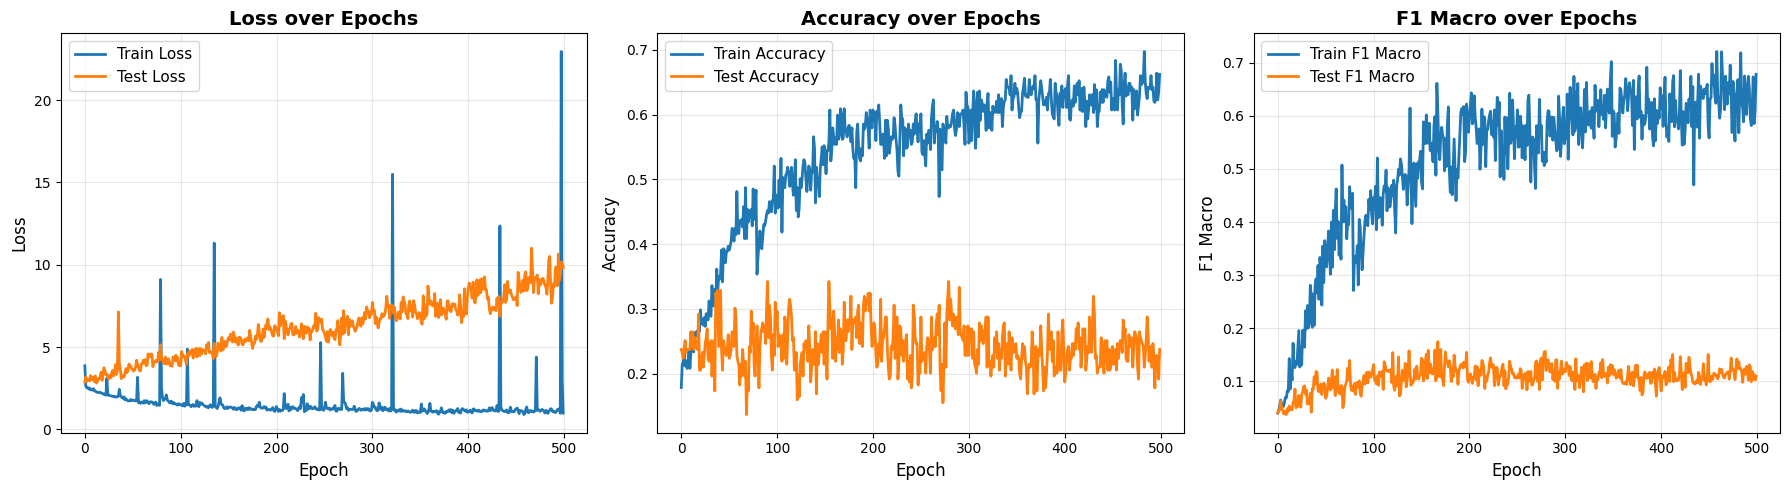

In [27]:
# ============ 5. PLOT METRICS ============
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# F1 Macro
axes[2].plot(train_f1s, label='Train F1 Macro', linewidth=2)
axes[2].plot(test_f1s, label='Test F1 Macro', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1 Macro', fontsize=12)
axes[2].set_title('F1 Macro over Epochs', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')

In [29]:
# ============ 6. EVALUATION ============
model.eval()
final_preds = []
final_labels = []

with torch.no_grad():
    for data in test_graphs:
        data = data.to(device)
        out = model(data)
        final_preds.append(out.argmax(dim=1).cpu().item())
        final_labels.append(data.y.cpu().item())

print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(final_labels, final_preds, target_names=le.classes_))


CLASSIFICATION REPORT (Test Set)
               precision    recall  f1-score   support

          201       0.33      0.80      0.47         5
          202       0.00      0.00      0.00         1
          208       0.06      0.33      0.10         3
          210       0.07      0.33      0.12         3
          213       0.00      0.00      0.00         4
          501       0.00      0.00      0.00         1
          503       0.00      0.00      0.00         1
          508       0.00      0.00      0.00         1
          510       0.00      0.00      0.00         1
          511       0.00      0.00      0.00         2
          512       0.12      0.33      0.18         3
          513       0.20      0.20      0.20         5
          515       0.00      0.00      0.00         1
          520       0.00      0.00      0.00         4
          522       0.00      0.00      0.00         3
          523       0.33      0.33      0.33         9
     Bathroom       0.00      

/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/agung/Documents/dsai/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []